In [73]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import stats

In [5]:
np.random.seed(42)

# A) CLT Visual Demonstration

In [26]:
population = np.random.exponential(scale=10, size=100000)
population_mean = np.mean(population)
population_std = np.std(population)
print(f"{population_mean = }")
print(f"{population_std = }")

population_mean = np.float64(10.048117660821985)
population_std = np.float64(10.098675653798358)


In [25]:
REPEAT = 5000
sample_means = []
Ns = (2, 5, 10, 30, 50, 100)
for n in Ns:
    sample_means.append([])
    for _ in range(5000):
        sample_means[-1].append(np.mean(np.random.choice(population, size=n, replace=True)))

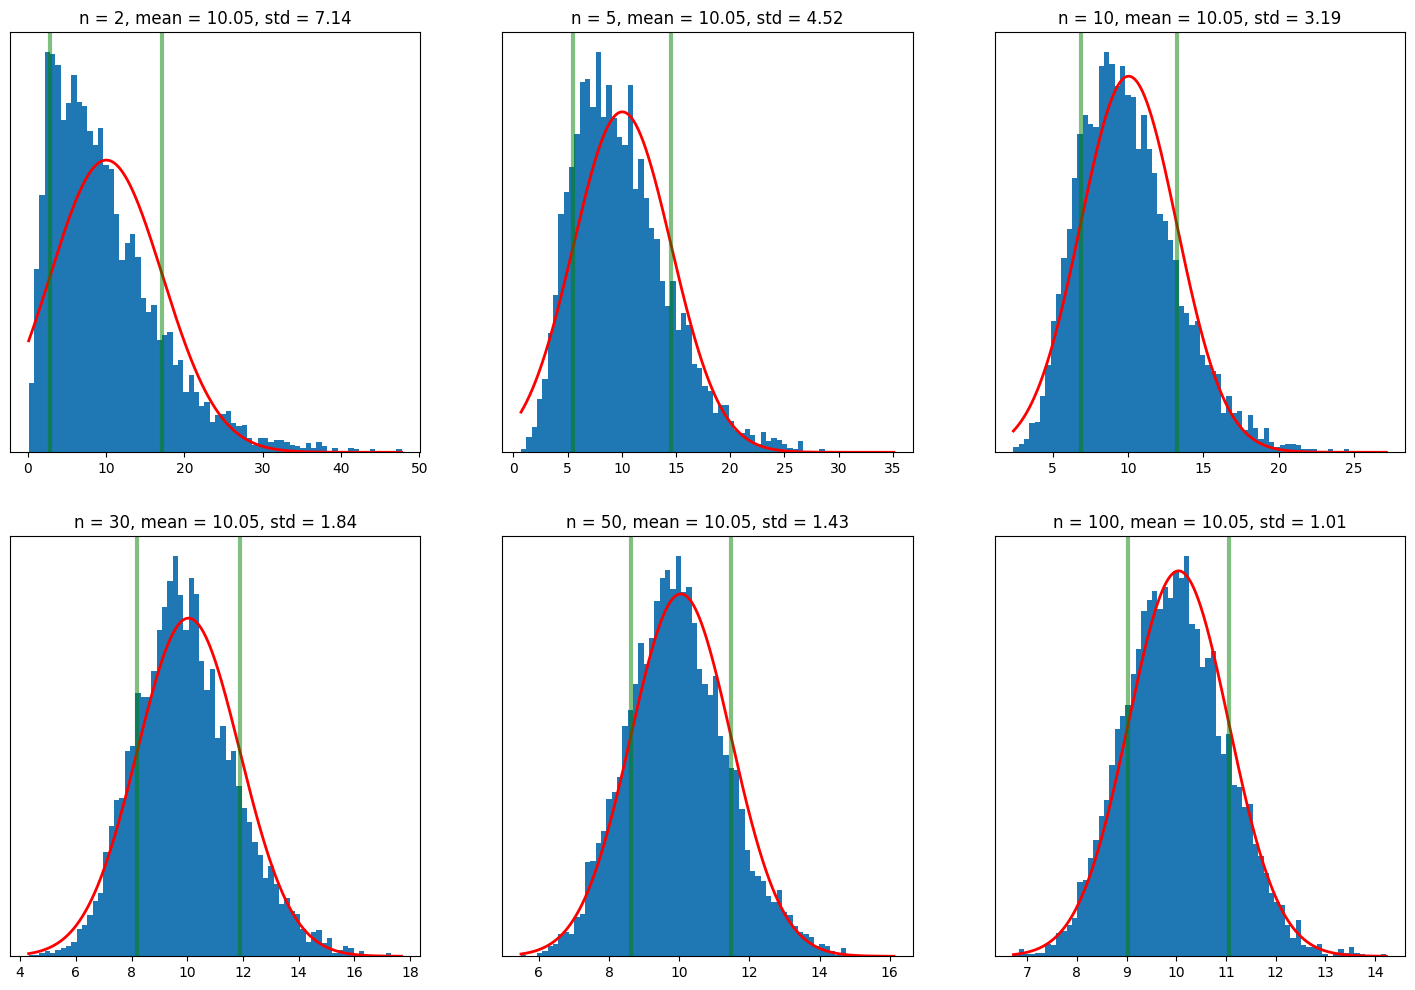

In [38]:
bins = int(5000 ** 0.5)
plt.figure(figsize=(18, 12))
for i in range(2):
    for j in range(3):
        ind = 3*i + j 
        plt.subplot(2, 3, ind + 1)
        n = Ns[ind]
        mean = population_mean
        std = population_std / (n ** 0.5)

        plt.title(f"{n = }, mean = {mean:.2f}, std = {std:.2f}")
        plt.yticks([])
        plt.hist(sample_means[ind ], bins = bins, density=True)

        x = np.linspace(min(sample_means[ind]), max(sample_means[ind]), 1000)
        y = stats.norm.pdf(x, mean, std)

        plt.plot(x, y, 'r-', linewidth=2)
        plt.axvline(mean + std, lw=3, alpha=0.5, c="g")
        plt.axvline(mean - std, lw=3, alpha=0.5, c="g")


In [39]:
"""
1. At n = 30, distribution seems normal (before that, it wasn't very symmetric)
2. variance will become smaller (but the min and max increase)
3. No
4. We can see that by getting samples of size 30, the means look like a normal distribution, mean is consistent around population mean and variance become smaller by increasing n (it has a reverse relation with sqrt(n)). 
CLT states that the distribution of X_n is Normal(mu, sigma/sqrt(n)) so we are seeing what CLT states theoretically
"""

"\n1. At n = 30, distribution seems normal (before that, it wasn't very symmetric)\n2. variance will become smaller (but the min and max increase)\n3. No\n4. We can see that by getting samples of size 30, the means look like a normal distribution, mean is consistent around population mean and variance become smaller by increasing n (it has a reverse relation with sqrt(n)). \nCLT states that the distribution of X_n is Normal(mu, sigma/sqrt(n)) so we are seeing what CLT states theoretically\n"

# B) Confidence Interval Coverage

In [57]:
def simulate_ci(n: int, alpha: float):
    Z_index = 0.5 + alpha/2
    Z = stats.norm.ppf(Z_index)
    REPEAT = 5000

    results = []
    for _ in range(REPEAT):
        
        x_bar = np.mean(np.random.normal(loc=50, scale=10, size=n))
        ci_l = x_bar - Z * 10 / n**0.5
        ci_r = x_bar + Z * 10 / n**0.5

        
        results.append( ci_l < 50 < ci_r)

    fitted = np.count_nonzero(results)
    return fitted
fitted = simulate_ci(40, 0.95)
print(f"Coverage rate: {fitted} / 5000 = {fitted / 5000}")

Coverage rate: 4736 / 5000 = 0.9472


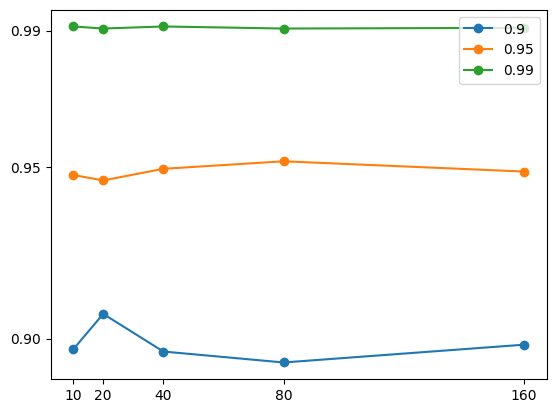

In [67]:
Ns = (10, 20, 40, 80, 160)
confidences = (0.9, 0.95, 0.99)
plot_count = 1
for confidence in confidences:
    coverage = []
    for n in Ns:
        coverage.append(simulate_ci(n, confidence)/ 5000)
    plt.plot(Ns, coverage, label=confidence, marker="o")

plt.xticks(Ns)
plt.yticks((0.9, 0.95, 0.99))
plt.legend()

In [ ]:

# B.4
"""
1. The CLT is fully applied at n = inf. at these n, the distribution is not a full normal. also there is the sampling inaccuracy. for example, even with a fair coin in a sample we might see that number of heads are twice the number of tails. but even at n = 10, we can see that it almost works.
2. It only improve the normal shape of distribution (CLT). not the CI since in CI, it already normalize it with n (to get sampling variance). so by increasing n, we expect to see a little more consistency in covergance (but not much, we know that at n = 30 distribution is almost normal).
3. It is in the definition! by choosing more confidence, the width of interval grows so it can capture more means. 
"""

# C) Sample Size Calculator

In [69]:
def required_sample_size(sigma: float, margin_of_error: float, confidence_level: float):
    """
    Calculate required n for given ME and confidence level
    Parameters:
    sigma: population standard deviation
    margin_of_error: desired ME
    confidence_level: 0.90, 0.95, or 0.99
    Returns:
    n: required sample size (rounded up)
    """
    # Your code here
    Z_index = 0.5 + confidence_level/2
    Z = stats.norm.ppf(Z_index)
    # Z * sigma / sqrt(n) = margin
    # n = (z * sigma / margin)**2
    return (Z * sigma / margin_of_error)**2

In [76]:
print("sigma, margin of error, 0.9 CI, 0.95 CI, 0.99 CI")
for sigma in (0.1, 0.2):
    for me in (0.01, 0.02):
        tmp = []
        for confidence in (0.9, 0.95, 0.99):
            n = required_sample_size(
                sigma=sigma,
                margin_of_error=me,
                confidence_level=confidence
            )
            tmp.append(math.ceil(n))
        print(sigma, me, *tmp)

sigma, margin of error, 0.9 CI, 0.95 CI, 0.99 CI
0.1 0.01 271 385 664
0.1 0.02 68 97 166
0.2 0.01 1083 1537 2654
0.2 0.02 271 385 664


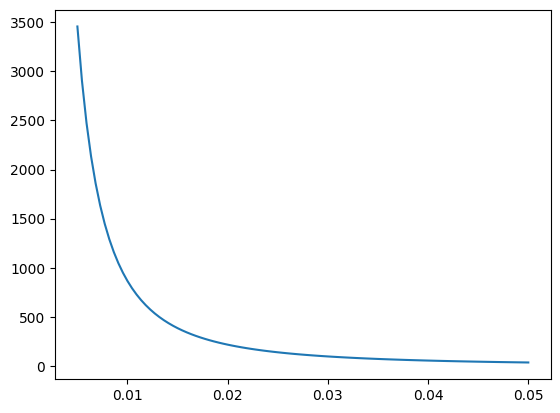

In [80]:

x = np.linspace(0.005, 0.05, 100)
y = [required_sample_size(sigma=0.15, margin_of_error=i, confidence_level=0.95) for i in x]
plt.plot(x, y)


In [81]:
""" 
1. because in the formula we got K / ME^2 so it is non linear.
2. to be able to pin down the mean to a very small interval, we need more data so we can be sure.
3. we can easily narrow interval from 0.05 to 0.02 but to be able to make it from 0.02 to 0.01 we need more data. it is not linear and it is hard, so we must first find the biggest acceptable interval and then initiate the survey process.
"""

' \n1. because in the formula we got K / ME^2 so it is non linear.\n2. to be able to pin down the mean to a very small interval, we need more data so we can be sure.\n3. we can easily narrow interval from 0.05 to 0.02 but to be able to make it from 0.02 to 0.01 we need more data. it is not linear and it is hard, so we must first find the biggest acceptable interval and then initiate the survey process.\n'

In [83]:
print(required_sample_size(sigma=0.15, margin_of_error=0.03, confidence_level=0.95))
print(required_sample_size(sigma=0.15, margin_of_error=0.01, confidence_level=0.95))

96.03647051735315
864.3282346561782
